# Testing the two-point FPP model


Here we consider the normalized, time-dependent two-point model derived by the Trapezoid rule on the momentum equation only.

\begin{align}
\partial_t T_t &= T_t^{3/2} - q T_u  T_t^2 \\
T_u &= \left(T_t^{7/2}+Q\right)^{2/7} \\
q &= \frac{\gamma n_u c_{s,0} T_0}{2 q_\parallel} \\
Q &= \frac{7}{2} \frac{q_\parallel L_\parallel}{\kappa_{0,e} T_0^{7/2}} \\
q_\parallel &= \gamma n_t c_{s,t} T_t
\end{align}
Here, time is normalized to 
$\frac{L_\parallel}{2 c_{s,t}(t=0)}$ and $T_t$ and $T_u$ are both normalized to a reference temperature $T_0$. Taking $L_\parallel \sim 10 m$, $c_s \sim 10^4 m/s$ and $\tau_d \sim 10 \mu s$ we typically have normalized $\tau_d \sim 10^{-2}$.



This model has a stable fixpoint corresponding to the equilibrium value. 

We take $q$ to be an FPP with $\Gamma$-2 pulse shape, and $Q, q_\parallel$ are parameters. The pulse duration time is a free parameter.



__OBS! The following system has no stable fixpoints!__


Here we consider the normalized, time-dependent two-point model derived by the Trapezoid rule in the sheat-limited regime ($T_u \approx T_t = T$)

\begin{align}
\partial_t n_t + T^{1/2} n_t + \partial_t n_u &= 0 \\
\frac{1}{2} n_t \partial_t T + T \partial_t n_u + T^{3/2} (n_t-n_u)  &= 0 \\
n_t(0) = 1/2 &\quad T(0) = 1
\end{align}
We take $n_u$ (which is normalized to its mean value) to be an FPP with $\Gamma$-2 pulse shape. The pulse duration time is a free parameter.

Note that time is normalized to 
$\frac{L_\parallel}{2 c_{s,t}(t=0)}$. Taking $L_\parallel \sim 10 m$, $c_s \sim 10^4 m/s$ and $\tau_d \sim 10 \mu s$ we typically have normalized $\tau_d \sim 10^{-2}$.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import jit
from scipy.integrate import solve_ivp

In [2]:
@jit
def phi(x):
    if x>0:
        return x*np.exp(-x)
    return 0

@jit
def FPP(t,td,s,A):
    res = 0
    for k in range(s.size):
        res += A[k]*phi((t-s[k])/td)
    return res

@jit
def FPP_array(tb,td,s,A):
    Phi = np.zeros_like(tb)
    for i in range(len(tb)):
        Phi[i] = FPP(tb[i],td,s,A)
    return Phi

In [3]:
class TwoPointFluct:
    def __init__(self, tmax=10., q_mean=1., Q=1.,
                 fluct = True, td=1e-1, gamma=1., A_mean=1):

        # q = q_b + q_fpp, so <q> = q_b + gamma <A>. 
        # Thus q = <q> ( 1+ (q_fpp-gamma<A>)/<q>) which requires 
        # <A> < <q>/gamma to be positive.

        if fluct==True:
            assert(gamma*A_mean<q_mean),'The forcing should be positive'
        
        self.tmax=tmax
        
        self.q_mean = q_mean
        self.Q = Q
        
        self.fluct = fluct
        self.td = td
        self.gamma = gamma
        self.A_mean = A_mean

    
    def realize_fpp(self,tmax):
        tw = self.td/self.gamma
        # Define the FPP a little outside of the domain to avoid issues with solve_ivp hitting boundaries
        K = np.random.poisson(1.02*tmax/tw)
        self.s = np.random.uniform(-0.01*tmax,1.01*tmax,size=K)
        self.A = self.A_mean*np.random.exponential(size=K)


        
    def run(self,tmax=10,Tt_init=0.1, dt_over_td=0.1):
        if self.fluct:
            self.realize_fpp(tmax)
            q = lambda t: self.q_mean*( 1+( FPP(t,self.td,self.s,self.A)-self.gamma*self.A_mean )/self.q_mean )
        else:
            q = lambda t: self.q_mean

        def Tu(Tt):
            return (Tt**(7/2)+self.Q)**(2/7)
            
        def _system(t,X):
            Tt = X[0]
            
            
            return Tt**1.5-q(t)*Tu(Tt)*Tt**2
        
        self.tb = np.arange(0,tmax,self.td*dt_over_td)
        res = solve_ivp(_system, [0,tmax], [Tt_init,], t_eval = self.tb)

        self.Tt = res.y[0]
        self.Tu = Tu(self.Tt)
        if self.fluct:
            self.q = self.q_mean*( 1+( FPP_array(self.tb,self.td,self.s,self.A)-self.gamma*self.A_mean )/self.q_mean )
        else:
            self.q = self.q_mean*np.ones_like(self.tb)

/tmp/ipykernel_84898/2539300169.py:46: RuntimeWarning: invalid value encountered in scalar power
  return Tt**1.5-q(t)*Tu(Tt)*Tt**2
/tmp/ipykernel_84898/2539300169.py:40: RuntimeWarning: invalid value encountered in scalar power
  return (Tt**(7/2)+self.Q)**(2/7)


Tt mean: 0.2666258010119598
Tt mean: 0.3083172846373104
Tt mean: 0.2661349990502515
Tt mean: 0.2680242198513283


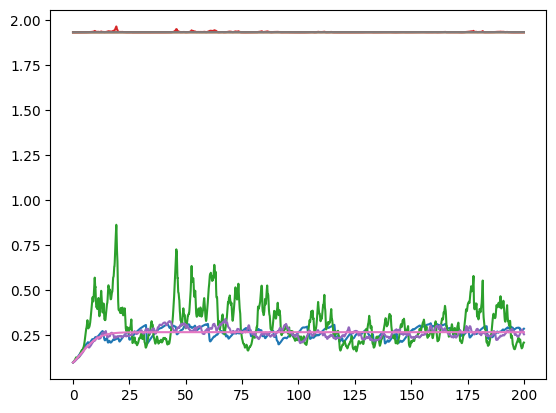

In [6]:
plt.figure()
for gamma,A_mean in zip([0.1, 1, 10, 1000],[1.,0.9,0.09,0.]):
    if gamma>100:
        T = TwoPointFluct(q_mean = 1, Q=10,fluct=False)
    else:
        T = TwoPointFluct(q_mean = 1, Q=10,gamma=gamma,A_mean=A_mean)
    
    T.run(200,0.1)
    
    plt.plot(T.tb, T.Tt)
    plt.plot(T.tb, T.Tu)

    print(f'Tt mean: {T.Tt[T.tb>20].mean()}')

/tmp/ipykernel_84898/2539300169.py:46: RuntimeWarning: invalid value encountered in scalar power
  return Tt**1.5-q(t)*Tu(Tt)*Tt**2
/tmp/ipykernel_84898/2539300169.py:40: RuntimeWarning: invalid value encountered in scalar power
  return (Tt**(7/2)+self.Q)**(2/7)


Tt mean: 0.9906358374805226
Tt mean: 1.042852306546794
Tt mean: 0.9849773125679723
Tt mean: 0.9807365192287895


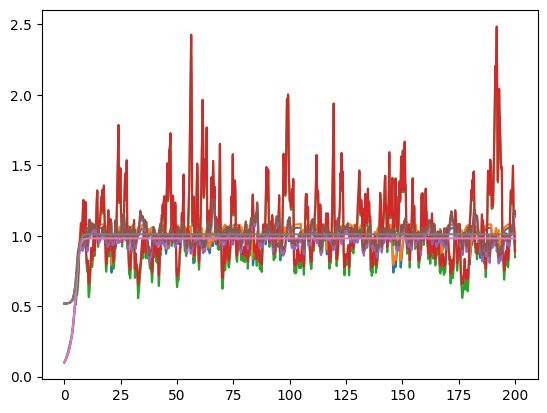

In [7]:
plt.figure()
for gamma,A_mean in zip([0.1, 1, 10, 1000],[1.,0.9,0.09,0.]):
    if gamma>100:
        T = TwoPointFluct(q_mean = 1, Q=0.1,fluct=False)
    else:
        T = TwoPointFluct(q_mean = 1, Q=0.1,gamma=gamma,A_mean=A_mean)
    
    T.run(200,0.1)
    
    plt.plot(T.tb, T.Tt)
    plt.plot(T.tb, T.Tu)

    print(f'Tt mean: {T.Tt[T.tb>20].mean()}')

Tt mean: 0.2686756682375148
Tt mean: 0.27024998035421693


/tmp/ipykernel_84898/2539300169.py:46: RuntimeWarning: invalid value encountered in scalar power
  return Tt**1.5-q(t)*Tu(Tt)*Tt**2
/tmp/ipykernel_84898/2539300169.py:40: RuntimeWarning: invalid value encountered in scalar power
  return (Tt**(7/2)+self.Q)**(2/7)


Tt mean: 0.31710483399993894


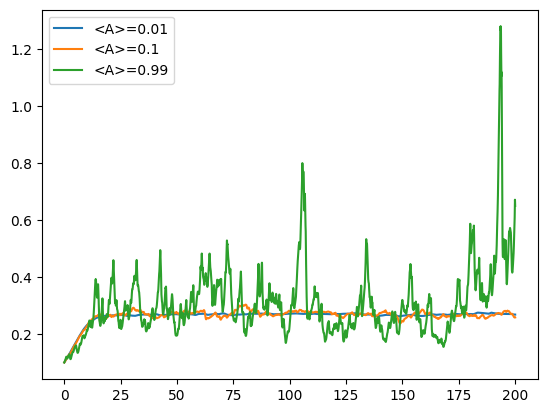

In [8]:
plt.figure()
gamma = 1.
for A_mean in [0.01,0.1,0.99]:
    T = TwoPointFluct(q_mean = 1, Q=10,gamma=gamma,A_mean=A_mean)
    
    T.run(200,0.1)
    
    plt.plot(T.tb, T.Tt,label=f'<A>={A_mean}')
    plt.legend()

    print(f'Tt mean: {T.Tt[T.tb>20].mean()}')

In [ ]:
tmax = 10
td = 1e-1
gamma = 0.5
tw = td/gamma

# Generate FPP arrivals
K = np.random.poisson(tmax/tw)

s = np.random.uniform(0,tmax,size=K)
A = np.random.exponential(size=K)

    
tb = np.linspace(0,tmax,1000)
Phi = FPP_array(tb,s,A)


plt.figure()
plt.plot(tb,Phi)
plt.figure()

In [ ]:
tmax = 100
td = 1e-1
gamma = 10.
tw = td/gamma
Q = 10

res, s, A = solve_system(tmax, td, gamma,Q,[0.1,])

tb = res.t
Tt = res.y[0,:]

Tu = (Tt**(7/2)+Q)**(2/7)
    
q = FPP_array(tb,s,A)

In [ ]:
plt.plot(tb, Tt)
plt.plot(tb,Tu)
#plt.plot(tb, q)

In [ ]:
e0 = 8.8e-12
me = 9e-31
mi = 2*1.6e-27
e = 1.6e-19
cs = 1e4
n=1e19

In [ ]:
tce = 3*np.pi**1.5*e0**2*me**0.5*mi**1.5*cs**3/(10*e**(4)*n)
lam = np.sqrt(mi/me)*cs*tce

In [ ]:
tce

In [ ]:
lam

In [ ]:
np.sqrt(mi/me)*lam/10

In [ ]:
np.sqrt(me/mi)

In [ ]:
x = np.linspace(0.,10,1000)
plt.figure()
plt.plot(x,f(x,10))
plt.plot(x,f(x,1))
plt.plot(x,f(x,0.1))

In [1]:
4**(-1/3)

0.6299605249474366